## Exploratory Data Analysis


In [1]:
import pandas as pd

df = pd.read_excel("Online Retail.xlsx")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


### Basic statistics

In [7]:
# Shape and column types
print("Shape:", df.shape)
print("\nColumn dtypes:")
print(df.dtypes)
print("\n--- Basic numeric summary ---")
df.describe()

Shape: (541909, 8)

Column dtypes:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object

--- Basic numeric summary ---


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [8]:
# Non-numeric columns and coverage metrics (for summary)
n_invoices = df["InvoiceNo"].nunique()
n_products = df["StockCode"].nunique()
n_countries = df["Country"].nunique()
date_min = df["InvoiceDate"].min()
date_max = df["InvoiceDate"].max()
n_customers = df["CustomerID"].nunique()  # excludes NaN
n_rows = len(df)

print("InvoiceNo (unique):", n_invoices)
print("StockCode (unique):", n_products)
print("Countries:", n_countries)
print("\nTop 5 countries by transaction count:")
print(df["Country"].value_counts().head())
print("\nDate range:", date_min, "to", date_max)

InvoiceNo (unique): 25900
StockCode (unique): 4070
Countries: 38

Top 5 countries by transaction count:
Country
United Kingdom    495478
Germany             9495
France              8557
EIRE                8196
Spain               2533
Name: count, dtype: int64

Date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00


### Data quality observations

In [9]:
# 1. Missing values (store for summary)
missing_per_col = df.isnull().sum()
n_missing_customerid = int(df["CustomerID"].isnull().sum())
n_missing_description = int(df["Description"].isnull().sum())
pct_missing_customerid = round(100 * n_missing_customerid / len(df), 1)
pct_missing_description = round(100 * n_missing_description / len(df), 1)

print("Missing values per column:")
print(missing_per_col)
print(f"\n% of rows with missing CustomerID: {pct_missing_customerid}%")
print(f"% of rows with missing Description: {pct_missing_description}%")

Missing values per column:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

% of rows with missing CustomerID: 24.9%
% of rows with missing Description: 0.3%


In [10]:
# 2. Data integrity: duplicates and invalid values (store for summary)
n_duplicates = int(df.duplicated().sum())
n_neg_quantity = int((df["Quantity"] <= 0).sum())
n_neg_or_zero_price = int((df["UnitPrice"] <= 0).sum())
cancel_mask = df["InvoiceNo"].astype(str).str.startswith("C", na=False)
n_cancelled_invoices = int(cancel_mask.sum())

print("Fully duplicate rows:", n_duplicates)
print("\nRows with Quantity <= 0:", n_neg_quantity)
print("Rows with UnitPrice <= 0:", n_neg_or_zero_price)
print("Rows with Quantity <= 0 OR UnitPrice <= 0:", int(((df["Quantity"] <= 0) | (df["UnitPrice"] <= 0)).sum()))
print("\nRows that look like cancellations (InvoiceNo starts with 'C'):", n_cancelled_invoices)

Fully duplicate rows: 5268

Rows with Quantity <= 0: 10624
Rows with UnitPrice <= 0: 2517
Rows with Quantity <= 0 OR UnitPrice <= 0: 11805

Rows that look like cancellations (InvoiceNo starts with 'C'): 9288


In [11]:
# 3. Sample of data quality issues
print("Sample of rows with Quantity <= 0:")
print(df[df["Quantity"] <= 0][["InvoiceNo", "StockCode", "Description", "Quantity", "UnitPrice"]].head(10))
print("\nSample of rows with missing CustomerID:")
print(df[df["CustomerID"].isnull()][["InvoiceNo", "Country", "Quantity", "UnitPrice"]].head(5))

Sample of rows with Quantity <= 0:
    InvoiceNo StockCode                        Description  Quantity  \
141   C536379         D                           Discount        -1   
154   C536383    35004C    SET OF 3 COLOURED  FLYING DUCKS        -1   
235   C536391     22556     PLASTERS IN TIN CIRCUS PARADE        -12   
236   C536391     21984   PACK OF 12 PINK PAISLEY TISSUES        -24   
237   C536391     21983   PACK OF 12 BLUE PAISLEY TISSUES        -24   
238   C536391     21980  PACK OF 12 RED RETROSPOT TISSUES        -24   
239   C536391     21484        CHICK GREY HOT WATER BOTTLE       -12   
240   C536391     22557   PLASTERS IN TIN VINTAGE PAISLEY        -12   
241   C536391     22553             PLASTERS IN TIN SKULLS       -24   
939   C536506     22960           JAM MAKING SET WITH JARS        -6   

     UnitPrice  
141      27.50  
154       4.65  
235       1.65  
236       0.29  
237       0.29  
238       0.29  
239       3.45  
240       1.65  
241       1.65  
93

In [13]:
# Data quality summary (numbers from cells above)
print("=" * 60)
print("DATA QUALITY SUMMARY")
print("=" * 60)
print("\n--- Missing values ---")
print(f"  CustomerID:  {n_missing_customerid:,} rows ({pct_missing_customerid}%)")
print(f"  Description: {n_missing_description:,} rows ({pct_missing_description}%)")
print("\n--- Data integrity ---")
print(f"  Duplicate rows:           {n_duplicates:,}")
print(f"  Rows with Quantity <= 0:  {n_neg_quantity:,}")
print(f"  Rows with UnitPrice <= 0: {n_neg_or_zero_price:,}")
print(f"  Cancelled invoices (C*): {n_cancelled_invoices:,} rows")
print("\n--- Data coverage ---")
print(f"  Date range:         {date_min.strftime('%Y-%m-%d')} to {date_max.strftime('%Y-%m-%d')}")
print(f"  Total transactions:         {n_rows:,}")
print(f"  Unique invoices:    {n_invoices:,}")
print(f"  Unique customers:   {n_customers:,} (excl. missing CustomerID)")
print(f"  Unique products:    {n_products:,} (StockCode)")
print(f"  Countries:          {n_countries}")
print("=" * 60)

DATA QUALITY SUMMARY

--- Missing values ---
  CustomerID:  135,080 rows (24.9%)
  Description: 1,454 rows (0.3%)

--- Data integrity ---
  Duplicate rows:           5,268
  Rows with Quantity <= 0:  10,624
  Rows with UnitPrice <= 0: 2,517
  Cancelled invoices (C*): 9,288 rows

--- Data coverage ---
  Date range:         2010-12-01 to 2011-12-09
  Total transactions:         541,909
  Unique invoices:    25,900
  Unique customers:   4,372 (excl. missing CustomerID)
  Unique products:    4,070 (StockCode)
  Countries:          38


### Data cleaning

In [14]:
# --- Before cleaning: capture stats ---
before = {
    "rows": len(df),
    "unique_invoices": df["InvoiceNo"].nunique(),
    "unique_customers": df["CustomerID"].nunique(),
    "unique_products": df["StockCode"].nunique(),
    "missing_any": df.isnull().any(axis=1).sum(),
    "duplicates": df.duplicated().sum(),
    "cancelled": df["InvoiceNo"].astype(str).str.startswith("C", na=False).sum(),
    "qty_le_zero": (df["Quantity"] <= 0).sum(),
    "price_le_zero": (df["UnitPrice"] <= 0).sum(),
}
# Revenue on raw (only where both Qty and Price > 0) for reference
before["revenue"] = df.loc[(df["Quantity"] > 0) & (df["UnitPrice"] > 0), ["Quantity", "UnitPrice"]].prod(axis=1).sum()

In [15]:
# --- Clean: work on a copy ---
df_clean = df.copy()

# Remove duplicate rows
df_clean = df_clean.drop_duplicates()

# Drop rows with missing values (CustomerID, Description, etc.)
df_clean = df_clean.dropna()

# Exclude cancelled invoices (InvoiceNo starting with "C")
df_clean = df_clean[~df_clean["InvoiceNo"].astype(str).str.startswith("C", na=False)]

# Exclude returns/invalid: keep only Quantity > 0 and UnitPrice > 0
df_clean = df_clean[(df_clean["Quantity"] > 0) & (df_clean["UnitPrice"] > 0)]

# Create Revenue column
df_clean["Revenue"] = df_clean["Quantity"] * df_clean["UnitPrice"]

In [16]:
# --- After cleaning: capture stats ---
after = {
    "rows": len(df_clean),
    "unique_invoices": df_clean["InvoiceNo"].nunique(),
    "unique_customers": df_clean["CustomerID"].nunique(),
    "unique_products": df_clean["StockCode"].nunique(),
    "missing_any": df_clean.isnull().any(axis=1).sum(),
    "duplicates": df_clean.duplicated().sum(),
    "revenue": df_clean["Revenue"].sum(),
}

In [17]:
# --- Before vs After ---
print("BEFORE (raw df)")
print("-" * 40)
print(f"  Rows:              {before['rows']:,}")
print(f"  Unique invoices:   {before['unique_invoices']:,}")
print(f"  Unique customers: {before['unique_customers']:,}")
print(f"  Unique products:  {before['unique_products']:,}")
print(f"  Rows with missing: {before['missing_any']:,}")
print(f"  Duplicate rows:   {before['duplicates']:,}")
print(f"  Cancelled (C*):   {before['cancelled']:,}")
print(f"  Quantity <= 0:    {before['qty_le_zero']:,}")
print(f"  UnitPrice <= 0:   {before['price_le_zero']:,}")
print(f"  Revenue (valid):  {before['revenue']:,.2f}")
print()
print("AFTER (df_clean)")
print("-" * 40)
print(f"  Rows:              {after['rows']:,}")
print(f"  Unique invoices:   {after['unique_invoices']:,}")
print(f"  Unique customers: {after['unique_customers']:,}")
print(f"  Unique products:  {after['unique_products']:,}")
print(f"  Rows with missing: {after['missing_any']:,}")
print(f"  Duplicate rows:   {after['duplicates']:,}")
print(f"  Total Revenue:    {after['revenue']:,.2f}")
print()
print(f"Rows removed: {before['rows'] - after['rows']:,} ({100 * (before['rows'] - after['rows']) / before['rows']:.1f}%)")

BEFORE (raw df)
----------------------------------------
  Rows:              541,909
  Unique invoices:   25,900
  Unique customers: 4,372
  Unique products:  4,070
  Rows with missing: 135,080
  Duplicate rows:   5,268
  Cancelled (C*):   9,288
  Quantity <= 0:    10,624
  UnitPrice <= 0:   2,517
  Revenue (valid):  10,666,684.54

AFTER (df_clean)
----------------------------------------
  Rows:              392,692
  Unique invoices:   18,532
  Unique customers: 4,338
  Unique products:  3,665
  Rows with missing: 0
  Duplicate rows:   0
  Total Revenue:    8,887,208.89

Rows removed: 149,217 (27.5%)


## Sales & revenue analysis (cleaned data)

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

### 1. Sales & revenue trends over time

Monthly sales & revenue summary
 YearMonth     Revenue  Orders  Items  Customers  Revenue_Per_Order  Revenue_MoM_Pct  Orders_MoM_Pct
2010-12-01  570422.730    1400 311048        885         407.444807              NaN             NaN
2011-01-01  568101.310     987 348473        741         575.583901        -0.406965      -29.500000
2011-02-01  446084.920     997 265027        758         447.427202       -21.477928        1.013171
2011-03-01  594081.760    1321 347582        974         449.721241        33.176831       32.497492
2011-04-01  468374.331    1149 291366        856         407.636493       -21.159954      -13.020439
2011-05-01  677355.150    1555 372864       1056         435.598167        44.618333       35.335074
2011-06-01  660046.050    1393 363014        991         473.830617        -2.555395      -10.418006
2011-07-01  598962.901    1331 367360        949         450.009693        -9.254377       -4.450826
2011-08-01  644051.040    1280 397373        935         50

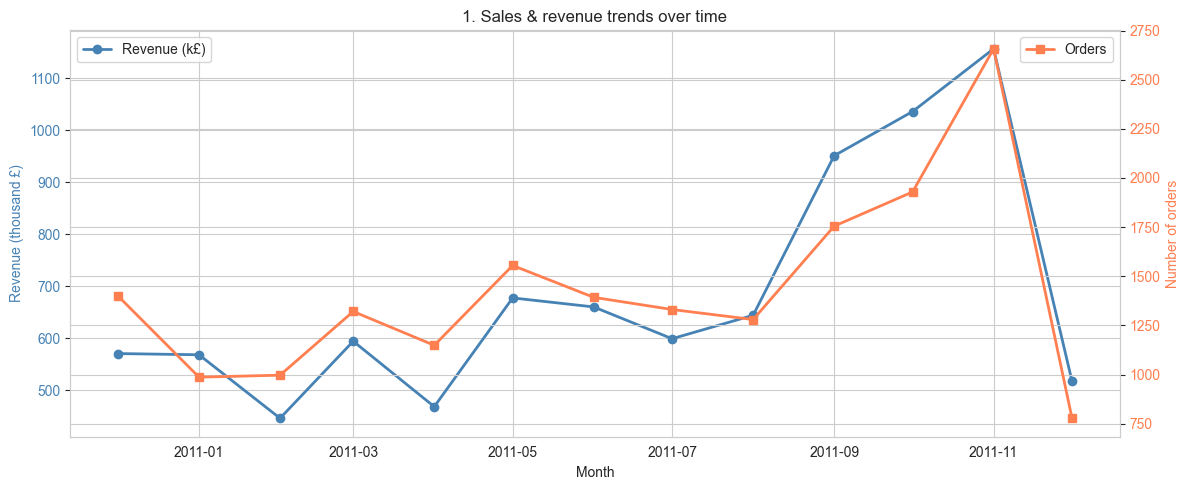

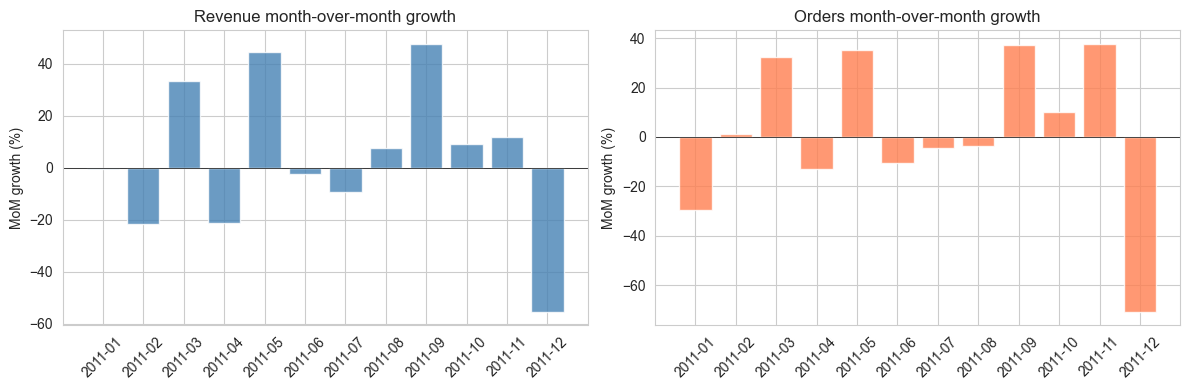

In [44]:
# --- Monthly aggregation ---
df_clean["YearMonth"] = df_clean["InvoiceDate"].dt.to_period("M")
monthly = df_clean.groupby("YearMonth").agg(
    Revenue=("Revenue", "sum"),
    Orders=("InvoiceNo", "nunique"),
    Items=("Quantity", "sum"),
    Customers=("CustomerID", "nunique"),
).reset_index()
monthly["YearMonth"] = monthly["YearMonth"].dt.to_timestamp()
monthly["Revenue_Per_Order"] = monthly["Revenue"] / monthly["Orders"]
monthly["Revenue_MoM_Pct"] = monthly["Revenue"].pct_change() * 100
monthly["Orders_MoM_Pct"] = monthly["Orders"].pct_change() * 100

print("Monthly sales & revenue summary")
print("=" * 80)
print(monthly.to_string(index=False))
print()

# --- Line chart: Revenue and order count over time ---
fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(monthly["YearMonth"], monthly["Revenue"] / 1e3, color="steelblue", marker="o", linewidth=2, label="Revenue (k£)")
ax1.set_ylabel("Revenue (thousand £)", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")
ax1.legend(loc="upper left")
ax2 = ax1.twinx()
ax2.plot(monthly["YearMonth"], monthly["Orders"], color="coral", marker="s", linewidth=2, label="Orders")
ax2.set_ylabel("Number of orders", color="coral")
ax2.tick_params(axis="y", labelcolor="coral")
ax2.legend(loc="upper right")
ax1.set_xlabel("Month")
plt.title("1. Sales & revenue trends over time")
plt.tight_layout()
plt.show()

# --- Month-over-month growth ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(monthly["YearMonth"].astype(str).str[:7], monthly["Revenue_MoM_Pct"], color="steelblue", alpha=0.8)
axes[0].axhline(0, color="black", linewidth=0.5)
axes[0].set_ylabel("MoM growth (%)")
axes[0].set_title("Revenue month-over-month growth")
axes[0].tick_params(axis="x", rotation=45)
axes[1].bar(monthly["YearMonth"].astype(str).str[:7], monthly["Orders_MoM_Pct"], color="coral", alpha=0.8)
axes[1].axhline(0, color="black", linewidth=0.5)
axes[1].set_ylabel("MoM growth (%)")
axes[1].set_title("Orders month-over-month growth")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

### 2. Geographic distribution

In [45]:
# Order-level totals (for AOV by country)
order_totals = df_clean.groupby("InvoiceNo").agg(
    Revenue=("Revenue", "sum"),
    Country=("Country", "first"),
).reset_index()

# By country: revenue, orders, customers, AOV, revenue per customer, etc.
geo = df_clean.groupby("Country").agg(
    Total_Revenue=("Revenue", "sum"),
    Total_Quantity=("Quantity", "sum"),
    Num_Orders=("InvoiceNo", "nunique"),
    Num_Customers=("CustomerID", "nunique"),
).reset_index()
order_by_country = order_totals.groupby("Country")["Revenue"].agg(
    ["mean", "median", "min", "max", "std", "count"]
).reset_index()
order_by_country.columns = [
    "Country", "Avg_Order_Value", "Median_Order_Value",
    "Min_Order_Value", "Max_Order_Value", "Order_Value_Std", "Order_Count"
]
geo = geo.merge(
    order_by_country[["Country", "Avg_Order_Value", "Median_Order_Value", "Min_Order_Value", "Max_Order_Value"]],
    on="Country"
)
geo["Revenue_Per_Customer"] = geo["Total_Revenue"] / geo["Num_Customers"]
geo["Revenue_Pct"] = 100 * geo["Total_Revenue"] / geo["Total_Revenue"].sum()
geo["Orders_Pct"] = 100 * geo["Num_Orders"] / geo["Num_Orders"].sum()
geo["Quantity_Per_Order"] = geo["Total_Quantity"] / geo["Num_Orders"]
geo = geo.sort_values("Total_Revenue", ascending=False).reset_index(drop=True)

print("2. Geographic distribution — summary by country")
print("=" * 100)
print(geo.to_string(index=False))

2. Geographic distribution — summary by country
             Country  Total_Revenue  Total_Quantity  Num_Orders  Num_Customers  Avg_Order_Value  Median_Order_Value  Min_Order_Value  Max_Order_Value  Revenue_Per_Customer  Revenue_Pct  Orders_Pct  Quantity_Per_Order
      United Kingdom    7285024.644         4241305       16646           3920       437.644157             298.280             0.38        168469.60           1858.424654    81.972020   89.823009          254.794245
         Netherlands     285446.340          200361          94              9      3036.663191             806.880             2.08         20277.92          31716.260000     3.211878    0.507231         2131.500000
                EIRE     265262.460          140133         260              3      1020.240231             678.520             1.45         16774.72          88420.820000     2.984767    1.402979          538.973077
             Germany     228678.400          119154         457             94      

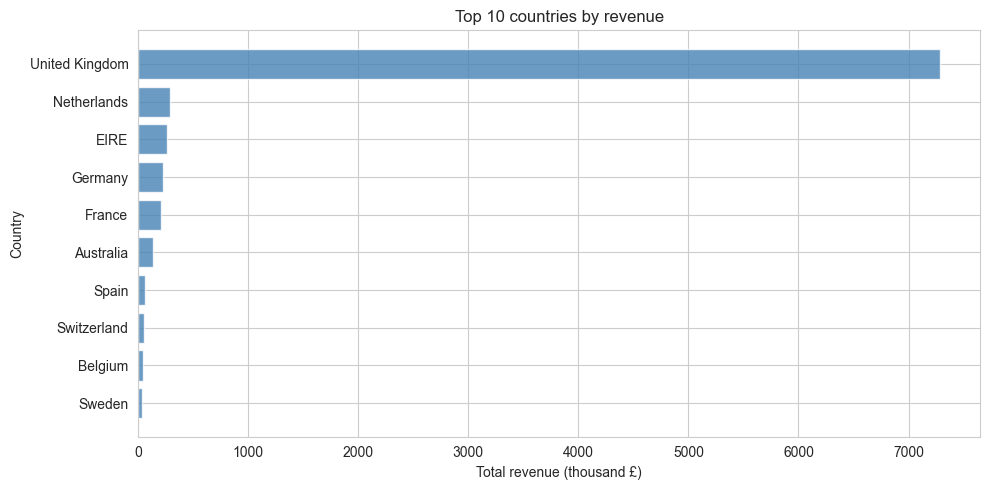

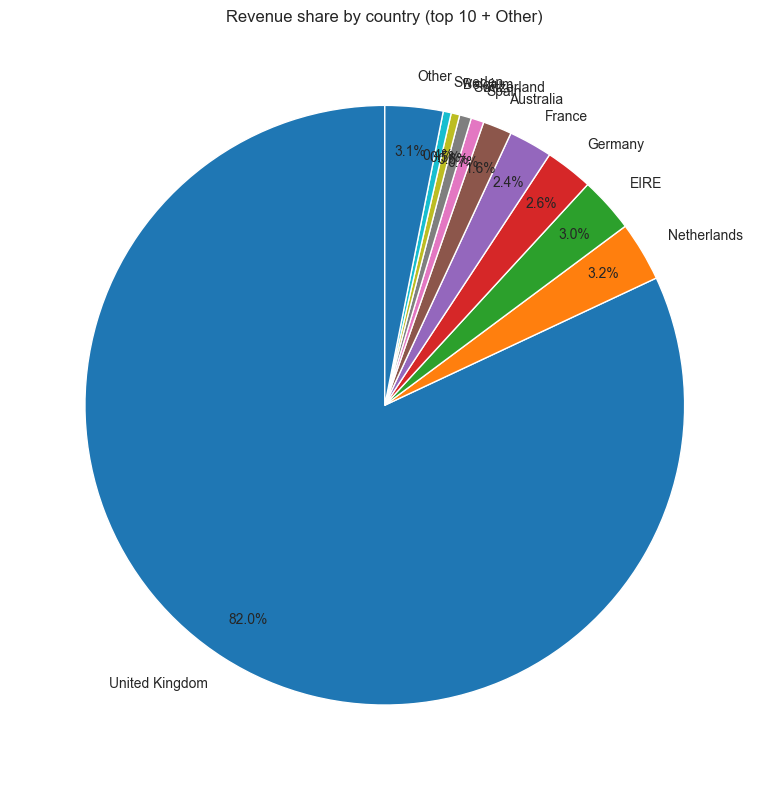

In [46]:
# Top 10 countries by revenue — bar chart
top10_countries = geo.head(10)
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top10_countries["Country"][::-1], top10_countries["Total_Revenue"][::-1] / 1e3, color="steelblue", alpha=0.8)
ax.set_xlabel("Total revenue (thousand £)")
ax.set_ylabel("Country")
ax.set_title("Top 10 countries by revenue")
plt.tight_layout()
plt.show()

# Revenue share by country — pie chart (top 10 + Other)
top10_rev = geo.head(10)
other_rev = geo["Total_Revenue"].iloc[10:].sum()
labels_pie = list(top10_rev["Country"]) + ["Other"]
sizes_pie = list(top10_rev["Total_Revenue"]) + [other_rev]
fig, ax = plt.subplots(figsize=(10, 8))
ax.pie(sizes_pie, labels=labels_pie, autopct="%1.1f%%", startangle=90, pctdistance=0.85)
ax.set_title("Revenue share by country (top 10 + Other)")
plt.tight_layout()
plt.show()

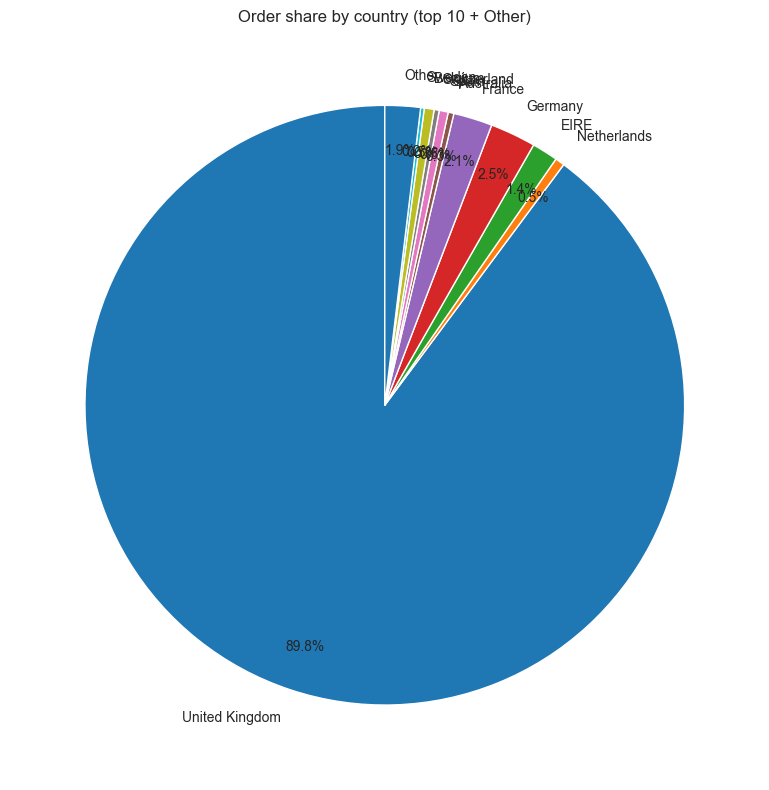

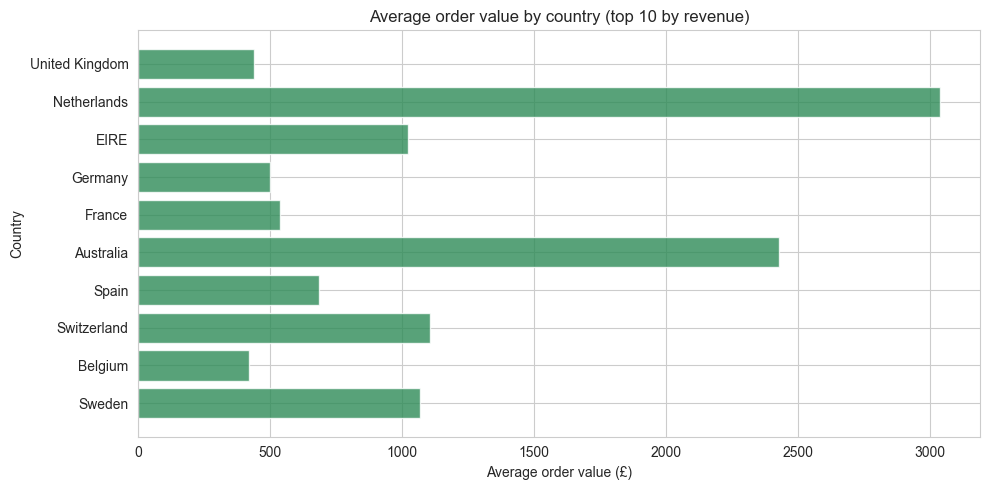

In [47]:
# Order share by country — pie chart (top 10 + Other)
sizes_orders = list(top10_rev["Num_Orders"]) + [geo["Num_Orders"].iloc[10:].sum()]
fig, ax = plt.subplots(figsize=(10, 8))
ax.pie(sizes_orders, labels=labels_pie, autopct="%1.1f%%", startangle=90, pctdistance=0.85)
ax.set_title("Order share by country (top 10 + Other)")
plt.tight_layout()
plt.show()

# Average order value by country (top 10 by revenue) — bar chart
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top10_countries["Country"][::-1], top10_countries["Avg_Order_Value"][::-1], color="seagreen", alpha=0.8)
ax.set_xlabel("Average order value (£)")
ax.set_ylabel("Country")
ax.set_title("Average order value by country (top 10 by revenue)")
plt.tight_layout()
plt.show()

### 3. Top performing products

In [48]:
# Product-level aggregation (StockCode + Description)
product = df_clean.groupby(["StockCode", "Description"]).agg(
    Revenue=("Revenue", "sum"),
    Quantity=("Quantity", "sum"),
    Num_Orders=("InvoiceNo", "nunique"),
).reset_index()
product = product.sort_values("Revenue", ascending=False).reset_index(drop=True)
product["Revenue_Pct"] = 100 * product["Revenue"] / product["Revenue"].sum()

print("Top 20 products by revenue")
print("=" * 100)
print(product.head(20).to_string(index=False))
print()
print("Top 20 products by quantity sold")
print("=" * 100)
product_by_qty = product.sort_values("Quantity", ascending=False).reset_index(drop=True)
print(product_by_qty.head(20).to_string(index=False))

Top 20 products by revenue
StockCode                        Description   Revenue  Quantity  Num_Orders  Revenue_Pct
    23843        PAPER CRAFT , LITTLE BIRDIE 168469.60     80995           1     1.895641
    22423           REGENCY CAKESTAND 3 TIER 142264.75     12374        1703     1.600781
   85123A WHITE HANGING HEART T-LIGHT HOLDER 100392.10     36706        1971     1.129625
   85099B            JUMBO BAG RED RETROSPOT  85040.54     46078        1600     0.956887
    23166     MEDIUM CERAMIC TOP STORAGE JAR  81416.73     77916         195     0.916111
     POST                            POSTAGE  77803.96      3120        1099     0.875460
    47566                      PARTY BUNTING  68785.23     15279        1379     0.773980
    84879      ASSORTED COLOUR BIRD ORNAMENT  56413.03     35263        1375     0.634767
        M                             Manual  53419.93      6933         253     0.601088
    23084                 RABBIT NIGHT LIGHT  51251.24     27153         

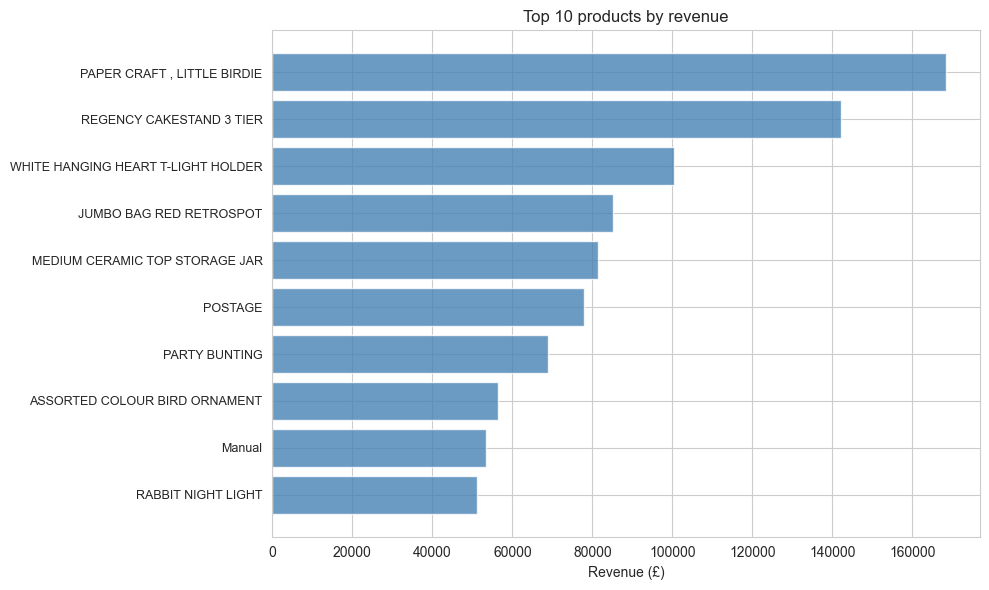

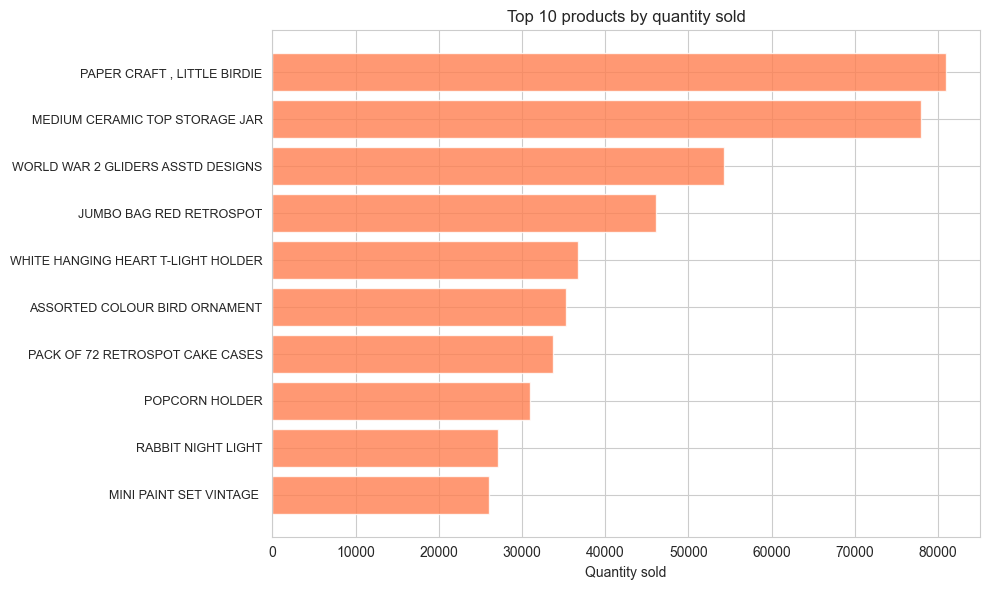

In [49]:
# Top 10 products by revenue — horizontal bar chart
top10_products = product.head(10)
fig, ax = plt.subplots(figsize=(10, 6))
labels = top10_products["Description"].str[:45]
ax.barh(range(len(top10_products)), top10_products["Revenue"], color="steelblue", alpha=0.8)
ax.set_yticks(range(len(top10_products)))
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel("Revenue (£)")
ax.set_title("Top 10 products by revenue")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# Top 10 products by quantity sold — horizontal bar chart
top10_qty = product_by_qty.head(10)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(top10_qty)), top10_qty["Quantity"], color="coral", alpha=0.8)
ax.set_yticks(range(len(top10_qty)))
ax.set_yticklabels(top10_qty["Description"].str[:45], fontsize=9)
ax.set_xlabel("Quantity sold")
ax.set_title("Top 10 products by quantity sold")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

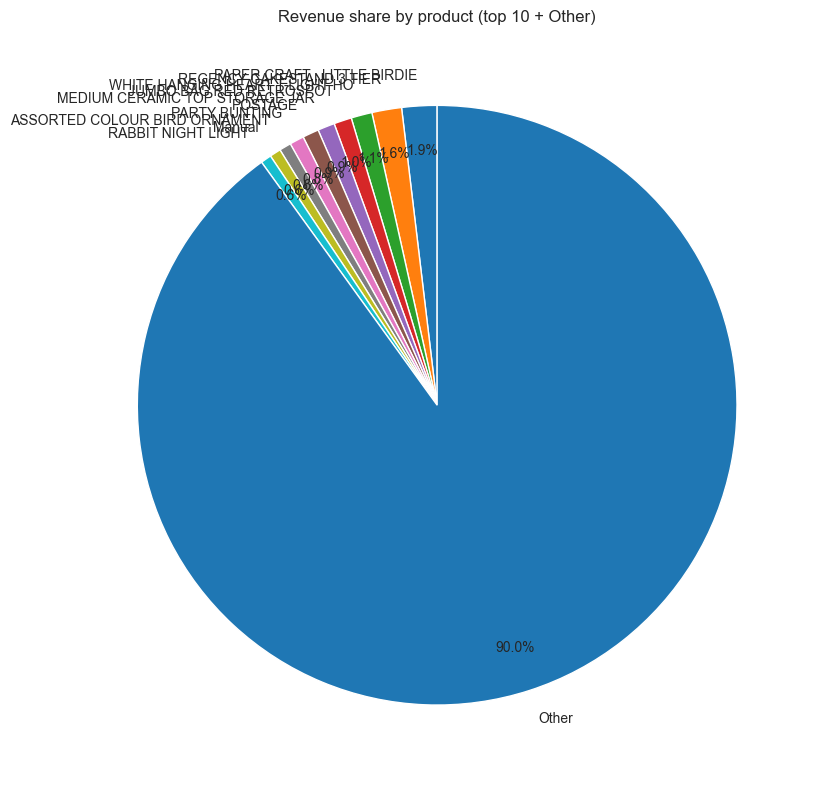

In [50]:
# Product revenue share — pie chart (top 10 + Other)
top10_prod_rev = product.head(10)
other_prod_rev = product["Revenue"].iloc[10:].sum()
labels_prod = list(top10_prod_rev["Description"].str[:30]) + ["Other"]
sizes_prod = list(top10_prod_rev["Revenue"]) + [other_prod_rev]
fig, ax = plt.subplots(figsize=(10, 8))
ax.pie(sizes_prod, labels=labels_prod, autopct="%1.1f%%", startangle=90, pctdistance=0.85)
ax.set_title("Revenue share by product (top 10 + Other)")
plt.tight_layout()
plt.show()

### Top product categories by revenue

Categories are derived from product descriptions (keyword-based). Revenue is aggregated by category to show which product types contribute most.

In [51]:
# Assign category from Description (keyword-based; order matters — first match wins).
# Categories aligned to keep "Miscellaneous" as small as possible.
def get_category(desc):
    if pd.isna(desc):
        return "Miscellaneous"
    d = str(desc).upper()
    # --- Postage & fees (keep separate) ---
    if "POSTAGE" in d or d.strip() == "MANUAL":
        return "Postage & fees"
    # --- Bags and packaging ---
    if "JUMBO BAG" in d or ("BAG" in d and "JUMBO" in d):
        return "Bags and packaging"
    if any(x in d for x in [" BAG ", "BAG ", " BAG", "BAGS ", " TOTE ", "PACKAGING", "CELLOPHANE", "WRAP ", " GIFT WRAP", "RIBBON REEL", "RIBBON REELS", "ROUND SNACK BAG", "LUNCH BAG", "BOTTLE BAG", "CARRIER BAG", "SHOPPING BAG", "PAPER BAG", "PLASTIC BAG", "METAL BAG"]):
        return "Bags and packaging"
    if "BAG" in d:
        return "Bags and packaging"
    # --- Food and beverage ---
    if any(x in d for x in ["JAM ", " JAM", "JAM JAR", "MARMALADE", "HONEY ", "CHOCOLATE", "BISCUIT", "COOKIE", "SWEET", "CANDY", "TEA COSY", "TEA COZIE", "COFFEE ", " SUGAR ", "MILK BOTTLE", "CREAM JUG", "RECIPE BOOK", "COOKBOOK"]):
        return "Food and beverage"
    if "JAM" in d:
        return "Food and beverage"
    # --- Kitchenware ---
    if any(x in d for x in ["CAKE TIN", "CAKESTAND", "CAKE STAND", "CAKE CASE", "CAKE CASES", "CAKE MOULD", "CAKE PLATE", "JELLY MOULD", "PANTRY JELLY", "BAKING ", "OVEN ", "KITCHEN ", "CUTLERY", "TEAPOT", "TEACUP", " MUG ", " MUGS", "EGG CUP", "EGG RING", "PIE FUNNEL", "BREAD BIN", "BREAD BASKET", "SCALES ", "KITCHEN SCALE", "COASTER", "COASTERS", "NAPKIN RING", "POT HOLDER", "OVEN GLOVE", "APRON ", "TEA TOWEL", "TOWEL ", "JUG ", " BOWL", "BOWLS ", "PLATE ", " PLATES", "CUP AND SAUCER", "TRIVET", "STORAGE JAR", "JAR ", " JARS", "BOTTLE ", " BOTTLES", "FLASK", "TRAY ", " TRAYS", "STORAGE BOX", "LUNCH BOX", "TIN ", " TINS"]):
        return "Kitchenware"
    if "JAR" in d or "STORAGE" in d:
        return "Kitchenware"
    if "CAKE" in d:
        return "Kitchenware"
    # --- Stationery ---
    if any(x in d for x in ["PEN ", " PENS", "PENCIL", "NOTEBOOK", "NOTEPAD", "NOTE PAD", "ENVELOPE", "LABEL ", " LABELS", "STICKER ", "RULER ", "ERASER", "HIGHLIGHTER", "CLIP ", " PAPERCLIP", "FILE ", " FOLDER", "DESK ", "ORGANISER", "ORGANIZER", "DIARY ", "CALENDAR", "ADVENT CALENDAR", "BOOKMARK", "MAGNET ", " LETTER ", "POSTCARD", "CARD HOLDER", "TISSUE BOX", "TISSUES ", " TISSUE "]):
        return "Stationery"
    if "TISSUE" in d:
        return "Stationery"
    # --- Party supplies ---
    if any(x in d for x in ["BUNTING", "BALLOON", "POPCORN ", "PARTY ", "CONFETTI", "CELEBRATION", "PAPER CHAIN", "TABLE CLOTH", "PAPER PLATE", "PAPER CUP", "CHRISTMAS CRACKER", "CRACKER ", " FAN "]):
        return "Party supplies"
    if "HOLDER" in d and any(x in d for x in ["CANDLE", "T-LIGHT", "NIGHT LIGHT", "TEA LIGHT", "POPCORN"]):
        return "Party supplies"
    if "FAN" in d and "PAPER" in d:
        return "Party supplies"
    # --- Craft supplies ---
    if any(x in d for x in ["PAINT SET", "PAINT BRUSH", "PAINT ", "CRAFT ", "PAPER CRAFT", "GLITTER", "GLUE ", " SEQUIN", "SEQUINS", "RIBBON ", " RIBBONS", "COLOUR ", "COLOR ", "STAMP ", " INK PAD", "SEWING ", "KNITTING", "SCRAPBOOK", "FELTCRAFT", "CARD KIT", "STICKER SHEET", "DECOUPAGE"]):
        return "Craft supplies"
    if "PAINT" in d:
        return "Craft supplies"
    if "SET" in d and any(x in d for x in ["CRAFT", "PAINT", "RIBBON", "COLOUR", "COLOURED", "SEWING", "STAMP", "PAPER", "CARD "]):
        return "Craft supplies"
    # --- Garden and outdoor ---
    if any(x in d for x in ["PICNIC", "GARDEN ", " PLANTER", "PLANTERS", "FLOWER POT", "FLOWERPOT", "SEED ", " BULB ", "BULBS ", "LAWN ", "SHED ", "GREENHOUSE", "OUTDOOR", "PATIO", "BIRD BATH", "FAIRY ", "GNOME ", "FROG ", "WOODEN SKIP", "BASKET "]):
        return "Garden and outdoor"
    if "BASKET" in d or "PICNIC" in d:
        return "Garden and outdoor"
    # --- Home decor ---
    if any(x in d for x in ["T-LIGHT", "NIGHT LIGHT", "LANTERN", "CHILLI LIGHT", "LIGHTS ", " LIGHTS", "DECORATIVE LIGHT", "CANDLE ", "CANDLES", "LAMP ", " LAMPS"]):
        return "Home decor"
    if "LIGHT" in d:
        return "Home decor"
    if any(x in d for x in ["ORNAMENT", "FIGURINE", " BIRD ", "BIRDS ", " RABBIT", "RABBITS", "DOLL ", "HEART ", "HEARTS ", "FAIRY", "GNOME", "SCULPTURE", "DECORATION", "TRINKET BOX", "VASE ", " VASES", "MIRROR ", "CLOCK ", "CLOCKS", "PICTURE ", "PHOTO FRAME", "WALL ART", "SIGN ", "CHALK BOARD", "BLACKBOARD", "DOOR STOP", "HANGING ", "COAT HANGER", "BLANKET ", "CUSHION ", "CURTAIN", "LAVENDER", "POTPOURRI", "BATHROOM SET", "HANGER ", "DOLL "]):
        return "Home decor"
    if "FRAME" in d or "BOARD" in d:
        return "Home decor"
    if "DOORMAT" in d or " DOOR MAT" in d:
        return "Home decor"
    if " MAT " in d or d.endswith(" MAT"):
        return "Home decor"
    if "BUNTING" in d:
        return "Home decor"
    if "ORNAMENT" in d or "BIRD" in d or "RABBIT" in d:
        return "Home decor"
    # --- Accessories / small personal (keep as named category to shrink Miscellaneous) ---
    if any(x in d for x in ["PURSE ", " WALLET", "KEY RING", "KEYRING", "KEY FOB", "RING BINDER", "HAND WARMER", "UMBRELLA", "GLASSES CASE", "CARD WALLET"]):
        return "Miscellaneous"
    if "PURSE" in d or "RING " in d:
        return "Miscellaneous"
    # --- Toys / music (small bucket) ---
    if any(x in d for x in ["HARMONICA", "MUSIC BOX", "TOY ", " TOYS", "DOLL ", "TEDDY", "PLUSH", "PUZZLE ", "GAME "]):
        return "Miscellaneous"
    if "MUSIC" in d:
        return "Miscellaneous"
    # --- Catch remaining "SET" that are likely craft/household ---
    if "SET" in d:
        return "Craft supplies"
    return "Miscellaneous"

df_clean["Category"] = df_clean["Description"].apply(get_category)
category_rev = df_clean.groupby("Category").agg(
    Total_Revenue=("Revenue", "sum"),
    Num_Products=("StockCode", "nunique"),
    Num_Orders=("InvoiceNo", "nunique"),
    Quantity=("Quantity", "sum"),
).reset_index()
category_rev["Revenue_Pct"] = 100 * category_rev["Total_Revenue"] / category_rev["Total_Revenue"].sum()
category_rev = category_rev.sort_values("Total_Revenue", ascending=False).reset_index(drop=True)

print("Revenue by product category (derived from description keywords)")
print("=" * 90)
print(category_rev.to_string(index=False))

Revenue by product category (derived from description keywords)
          Category  Total_Revenue  Num_Products  Num_Orders  Quantity  Revenue_Pct
     Miscellaneous    1889578.784          1397       15137   1393472    21.261780
        Home decor    1711929.350           751       13598    799897    19.262846
       Kitchenware    1603681.430           443       12916    793970    18.044827
Bags and packaging     989627.650           250        9289    700264    11.135416
    Craft supplies     899159.240           259       10493    508305    10.117454
    Party supplies     681324.340           160        9476    374258     7.666348
 Food and beverage     526796.960           159        9273    235028     5.927586
        Stationery     241141.230           153        6249    277942     2.713352
Garden and outdoor     200839.660           120        4212     58797     2.259873
    Postage & fees     143130.250             3        1368     10069     1.610520


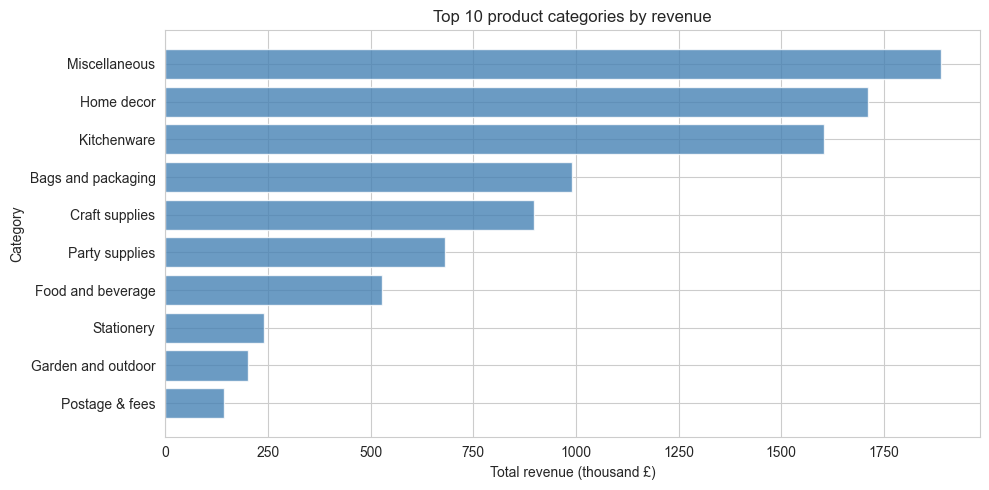

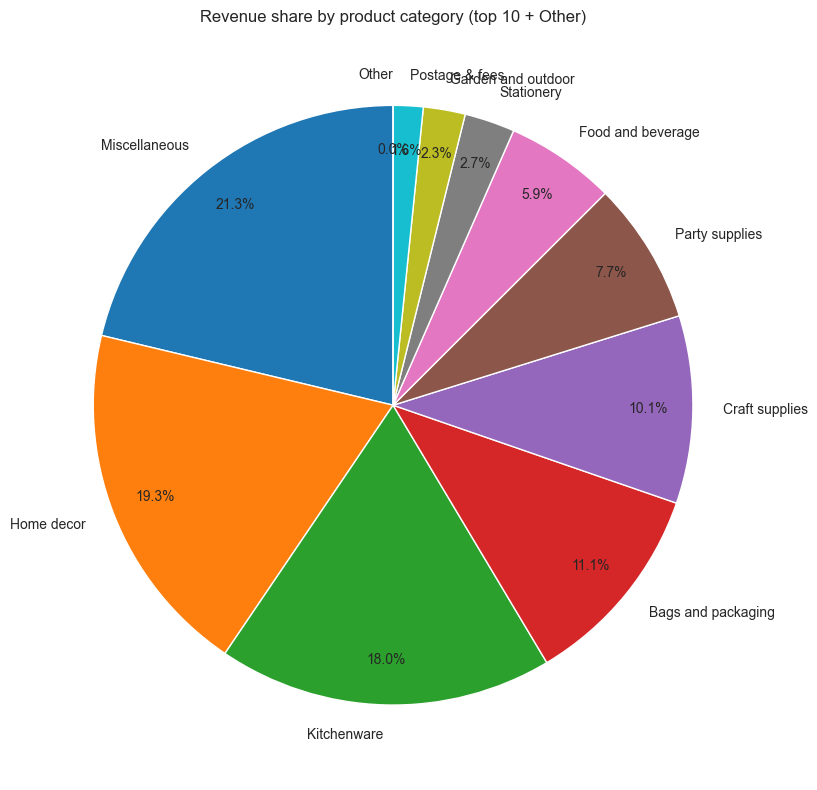

In [52]:
# Top 10 categories by revenue — bar chart
top10_cat = category_rev.head(10)
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top10_cat["Category"][::-1], top10_cat["Total_Revenue"][::-1] / 1e3, color="steelblue", alpha=0.8)
ax.set_xlabel("Total revenue (thousand £)")
ax.set_ylabel("Category")
ax.set_title("Top 10 product categories by revenue")
plt.tight_layout()
plt.show()

# Revenue share by category — pie chart (top 10 + Other)
top10_cat_rev = category_rev.head(10)
other_cat_rev = category_rev["Total_Revenue"].iloc[10:].sum()
labels_cat = list(top10_cat_rev["Category"]) + ["Other"]
sizes_cat = list(top10_cat_rev["Total_Revenue"]) + [other_cat_rev]
fig, ax = plt.subplots(figsize=(10, 8))
ax.pie(sizes_cat, labels=labels_cat, autopct="%1.1f%%", startangle=90, pctdistance=0.85)
ax.set_title("Revenue share by product category (top 10 + Other)")
plt.tight_layout()
plt.show()

### Strategic insights and recommendations

Key concentration metrics and actionable recommendations based on category revenue.

In [55]:
# Cumulative revenue share (categories already sorted by Total_Revenue)
category_rev["Cumulative_Revenue"] = category_rev["Total_Revenue"].cumsum()
total_rev = category_rev["Total_Revenue"].sum()
category_rev["Cumulative_Pct"] = 100 * category_rev["Cumulative_Revenue"] / total_rev

# Key concentration metrics
n_cats = len(category_rev)
pct_top3 = category_rev["Cumulative_Pct"].iloc[min(2, n_cats - 1)]
pct_top5 = category_rev["Cumulative_Pct"].iloc[min(4, n_cats - 1)]
pct_top10 = category_rev["Cumulative_Pct"].iloc[min(9, n_cats - 1)] if n_cats >= 10 else category_rev["Cumulative_Pct"].iloc[-1]
top3_names = ", ".join(category_rev["Category"].iloc[:3].tolist())

print("Revenue concentration by category")
print("=" * 60)
print(f"  Top  3 categories drive  {pct_top3:.1f}%  of revenue")
print(f"  Top  5 categories drive  {pct_top5:.1f}%  of revenue")
print(f"  Top 10 categories drive  {pct_top10:.1f}%  of revenue")
print("=" * 60)
print()
print("Insights")
print("-" * 60)
print(f"• Revenue is highly concentrated: the top 3 categories ({top3_names})")
print(f"  account for ~{pct_top3:.0f}% of revenue — focus here has outsized impact.")
print(f"• The top 5 categories cover ~{pct_top5:.0f}% of revenue; the long tail (remaining categories)")
print(f"  contributes ~{100 - pct_top5:.0f}% — consider prioritising assortment and stock for the core five.")
print(f"• Miscellaneous is a large bucket; refining product taxonomy or reassigning descriptions")
print("  could improve reporting and targeting.")
print()


Revenue concentration by category
  Top  3 categories drive  58.6%  of revenue
  Top  5 categories drive  79.8%  of revenue
  Top 10 categories drive  100.0%  of revenue

Insights
------------------------------------------------------------
• Revenue is highly concentrated: the top 3 categories (Miscellaneous, Home decor, Kitchenware)
  account for ~59% of revenue — focus here has outsized impact.
• The top 5 categories cover ~80% of revenue; the long tail (remaining categories)
  contributes ~20% — consider prioritising assortment and stock for the core five.
• Miscellaneous is a large bucket; refining product taxonomy or reassigning descriptions
  could improve reporting and targeting.



### 4. Average order value (AOV)

4. Average order value (AOV) — summary statistics
  Mean (AOV): 479.56
  Median: 302.57
  Min: 0.38
  Max: 168,469.60
  Std: 1,678.08
  25th percentile: 157.34
  75th percentile: 469.57
  90th percentile: 820.78
  95th percentile: 1,232.98
  Total orders: 18,532


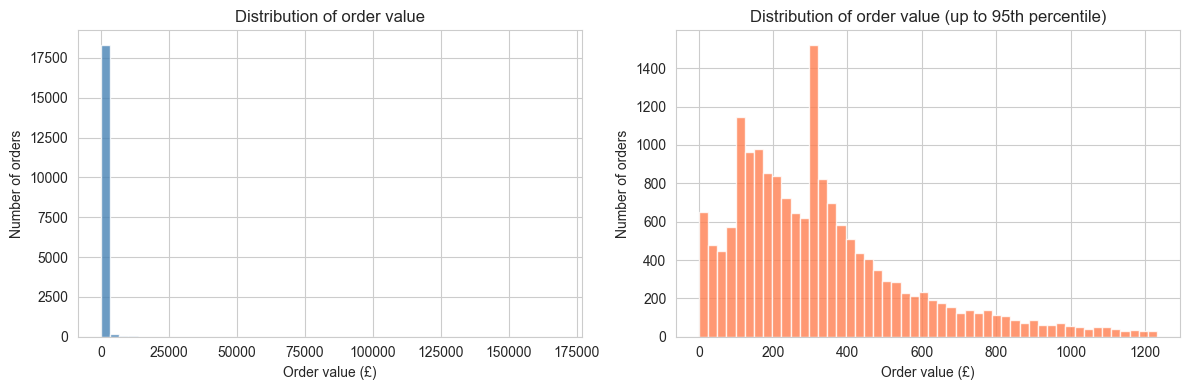

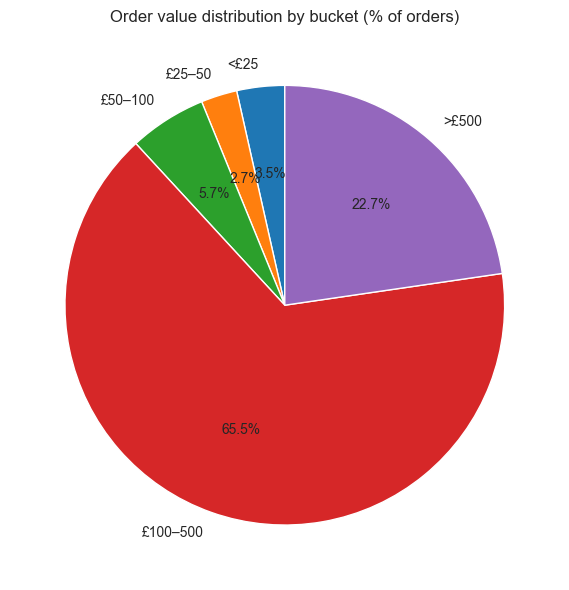

In [54]:
# Order value = total Revenue per invoice
order_value = df_clean.groupby("InvoiceNo")["Revenue"].sum()

# Summary statistics table
print("4. Average order value (AOV) — summary statistics")
print("=" * 60)
stats = {
    "Mean (AOV)": order_value.mean(),
    "Median": order_value.median(),
    "Min": order_value.min(),
    "Max": order_value.max(),
    "Std": order_value.std(),
    "25th percentile": order_value.quantile(0.25),
    "75th percentile": order_value.quantile(0.75),
    "90th percentile": order_value.quantile(0.90),
    "95th percentile": order_value.quantile(0.95),
    "Total orders": len(order_value),
}
for k, v in stats.items():
    if isinstance(v, float):
        print(f"  {k}: {v:,.2f}")
    else:
        print(f"  {k}: {v:,}")
print("=" * 60)

# Order value distribution — histogram (full and zoomed)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(order_value, bins=50, color="steelblue", edgecolor="white", alpha=0.8)
axes[0].set_xlabel("Order value (£)")
axes[0].set_ylabel("Number of orders")
axes[0].set_title("Distribution of order value")
p95 = order_value.quantile(0.95)
axes[1].hist(order_value[order_value <= p95], bins=50, color="coral", edgecolor="white", alpha=0.8)
axes[1].set_xlabel("Order value (£)")
axes[1].set_ylabel("Number of orders")
axes[1].set_title("Distribution of order value (up to 95th percentile)")
plt.tight_layout()
plt.show()

# Order value share by bucket — pie chart (e.g. &lt;25, 25–50, 50–100, 100–500, &gt;500)
bins = [0, 25, 50, 100, 500, order_value.max() + 1]
labels_bucket = ["<£25", "£25–50", "£50–100", "£100–500", ">£500"]
order_value_bucket = pd.cut(order_value, bins=bins, labels=labels_bucket)
bucket_counts = order_value_bucket.value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8, 6))
ax.pie(bucket_counts, labels=bucket_counts.index, autopct="%1.1f%%", startangle=90)
ax.set_title("Order value distribution by bucket (% of orders)")
plt.tight_layout()
plt.show()